##  ML Model Proposal
# **AquaYield**

### **Objectives**
The ML module aims to support sustainable agriculture by predicting three key factors:
1. Irrigation decision.
2. Water Efficiency level.
3. Plant Stress level.  
These predictions help optimize resource usage and improve crop health under varying environmental conditions.

### **Approach**
We use a Multi-Output Random Forest model because it:
- Handles multiple targets simultaneously.
- Works well with non-linear environmental data.
- Requires minimal data preprocessing.

Additionally, two engineered targets (Water_Efficiency and Plant_Stress) were created to enhance the model’s ability to understand plant condition.

### **Integration**
This ML component can be integrated into a larger smart-farming system, such as:
- IoT sensors for temperature, humidity, and moisture.
- A dashboard for farmers to receive irrigation recommendations.
- Automated irrigation systems that adjust water flow based on predictions.

### **Expected Benefits**
- Reduced water waste through optimized irrigation.
- Early detection of plant stress.
- Improved crop health and sustainability.
- Better decision-making without needing large or complex datasets.


In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [ ]:
# 1. Download dataset

path = kagglehub.dataset_download("chaitanyagopidesi/smart-agriculture-dataset")
print("Dataset folder:", path)

# Show files inside the dataset directory
print("Files inside folder:")
print(os.listdir(path))

# 2. Load the CSV file
# Pick the first CSV automatically
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
file_path = os.path.join(path, csv_files[0])

print("\nUsing file:", file_path)
df = pd.read_csv(file_path)
#-----------------
df.rename(columns={"result": "Irrigation"}, inplace=True)


100%|██████████| 66.1k/66.1k [00:00<00:00, 38.4MB/s]

Extracting files...
Dataset folder: /root/.cache/kagglehub/datasets/chaitanyagopidesi/smart-agriculture-dataset/versions/2
Files inside folder:
['cropdata_updated.csv']

Using file: /root/.cache/kagglehub/datasets/chaitanyagopidesi/smart-agriculture-dataset/versions/2/cropdata_updated.csv


In [ ]:
 # Custom function to compute water efficiency based on soil moisture and temperature


def water_efficiency(MOI, temp):
    if MOI > 3 and 20 <= temp <= 30:
        return 2   # High efficiency
    elif MOI < 2 and temp > 30:
        return 0   # Low efficiency
    else:
        return 1   # Medium efficiency

# Apply the water efficiency function
df['Water_Efficiency'] = df.apply(lambda row: water_efficiency(row['MOI'], row['temp']), axis=1)


# Custom function to compute plant stress based on temperature and humidity
def plant_stress(temp, humidity):
    if temp > 30 or humidity < 40:
        return 2   # High stress
    elif temp > 25 or humidity < 50:
        return 1   # Medium stress
    else:
        return 0   # No stress

# Apply the plant stress function
df['Plant_Stress'] = df.apply(lambda row: plant_stress(row['temp'], row['humidity']), axis=1)


# Ensure correct column naming
df.rename(columns={"result": "Irrigation"}, inplace=True)

print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
  crop ID   soil_type Seedling Stage  MOI  temp  humidity  Irrigation  \
0   Wheat  Black Soil    Germination    1    25      80.0           1   
1   Wheat  Black Soil    Germination    2    26      77.0           1   
2   Wheat  Black Soil    Germination    3    27      74.0           1   
3   Wheat  Black Soil    Germination    4    28      71.0           1   
4   Wheat  Black Soil    Germination    5    29      68.0           1   

   Water_Efficiency  Plant_Stress  
0                 1             0  
1                 1             1  
2                 1             1  
3                 2             1  
4                 2             1  


In [ ]:
# Check class distribution for each target variable
print(df['Irrigation'].value_counts())
print(df['Water_Efficiency'].value_counts())
print(df['Plant_Stress'].value_counts())

Irrigation
0    9062
1    6227
2    1122
Name: count, dtype: int64
Water_Efficiency
1    11036
2     5311
0       64
Name: count, dtype: int64
Plant_Stress
2    7240
0    6789
1    2382
Name: count, dtype: int64


In [ ]:
# Check for missing values in each column
df.isnull().sum()

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
Irrigation,0
Water_Efficiency,0
Plant_Stress,0


In [ ]:
# Count duplicated rows in the dataset
df.duplicated().sum()

np.int64(128)

In [ ]:
# Remove duplicated rows to clean the dataset
df.drop_duplicates(inplace=True)

In [ ]:
# 3. Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

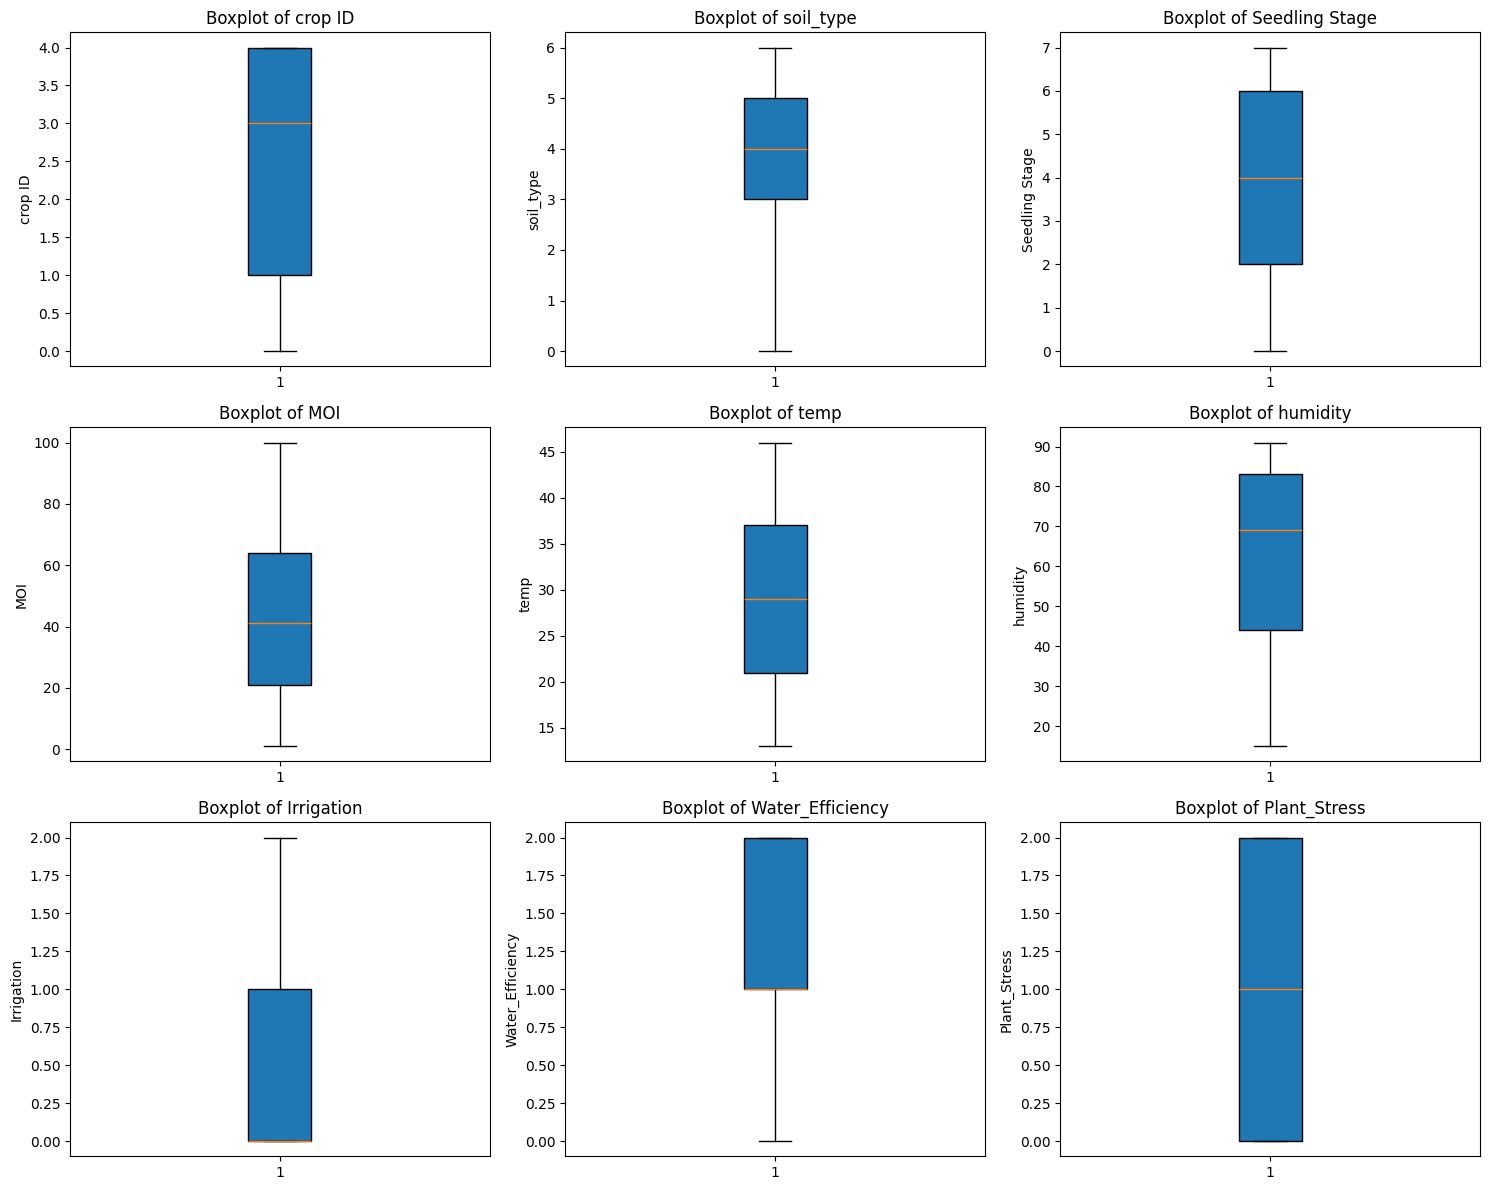

In [ ]:
#Visualize numeric features using boxplots

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Set the figure layout based on the number of columns
n_cols = 3  # Number of columns in the grid (you can change it)

n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # ceiling division

plt.figure(figsize=(n_cols*5, n_rows*4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col], vert=True, patch_artist=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
# Detect outliers using the IQR method

def detect_outliers_iqr(df):
    outlier_info = {}

    # Loop over numeric columns only
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter rows that are outside the allowed range

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_info[col] = {
            "count": len(outliers),
            "indices": outliers.index.tolist()
        }

    return outlier_info


# Detect outliers using the IQR method and store the result in a dictionary
outliers = detect_outliers_iqr(df)

# Display the dictionary containing outlier information for all numeric columns
# Each key = column name
# Each value = {"count": number of outliers, "indices": row positions}
outliers

{'crop ID': {'count': 0, 'indices': []},
 'soil_type': {'count': 0, 'indices': []},
 'Seedling Stage': {'count': 0, 'indices': []},
 'MOI': {'count': 0, 'indices': []},
 'temp': {'count': 0, 'indices': []},
 'humidity': {'count': 0, 'indices': []},
 'Irrigation': {'count': 0, 'indices': []},
 'Water_Efficiency': {'count': 0, 'indices': []},
 'Plant_Stress': {'count': 0, 'indices': []}}

**Data quality check**  
The dataset contains no missing values in any feature. A small number of duplicated rows were detected and removed. Using the IQR method, we did not find significant numeric outliers. Overall, the data is clean and ready for model training without additional preprocessing.



**Model choice:**  
We use a `RandomForestClassifier` wrapped in a `MultiOutputClassifier` so that we can predict three targets simultaneously: `Irrigation`, `Water_Efficiency`, and `Plant_Stress`. Random Forest is robust to non-linear relationships, handles mixed feature types, and works well with minimal hyperparameter tuning.



In [ ]:
#Train/test split and model training

# Feature matrix (input variables)
X = df[['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity']]

# Target matrix (multi-output labels)
y = df[['Irrigation', 'Water_Efficiency', 'Plant_Stress']]

# Split data into train (75%) and test (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Define a Random Forest as the base estimator
model = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, random_state=42))

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Print a classification report for each target variable
for i, col in enumerate(y.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))




--- Irrigation ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2267
           1       0.98      1.00      0.99      1552
           2       0.92      0.84      0.88       252

    accuracy                           0.98      4071
   macro avg       0.97      0.94      0.95      4071
weighted avg       0.98      0.98      0.98      4071


--- Water_Efficiency ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00      2704
           2       1.00      1.00      1.00      1353

    accuracy                           1.00      4071
   macro avg       1.00      1.00      1.00      4071
weighted avg       1.00      1.00      1.00      4071


--- Plant_Stress ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1711
           1       1.00      1.00      1.00       589
       

ROC-AUC for Irrigation (class 2 vs rest): 0.996


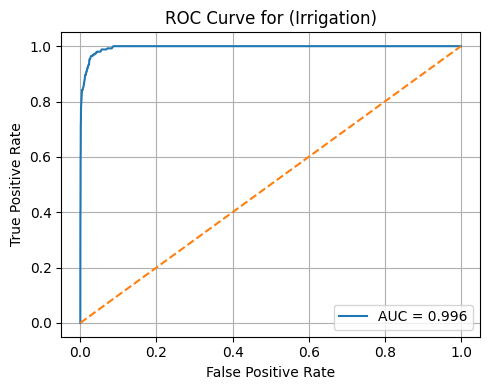

ROC-AUC for Water_Efficiency (class 2 vs rest): 1.000


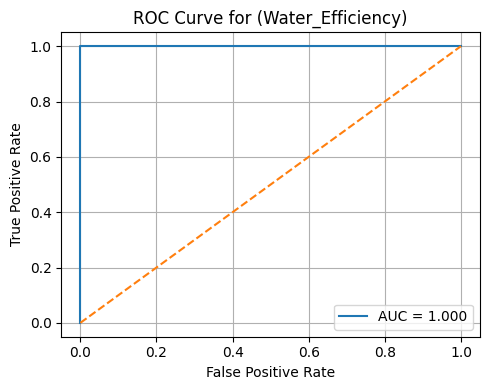

ROC-AUC for Plant_Stress (class 2 vs rest): 1.000


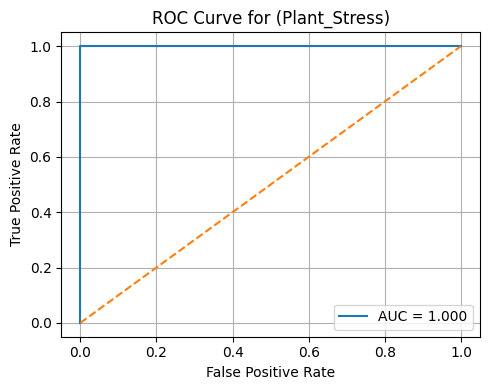

In [ ]:
# ROC–AUC curves for all targets (one-vs-rest with highest class as positive)
y_proba_all = model.predict_proba(X_test)

for i, target_name in enumerate(y.columns):
    # True labels for this target
    y_true = y_test.iloc[:, i]

    # Predicted probabilities for this target
    proba = y_proba_all[i]

    # Classes for this target
    classes = np.sort(y_true.unique())

    # Use highest class as positive
    pos_class = classes[-1]
    pos_index = list(classes).index(pos_class)

    # Scores = probability of the positive class
    y_score = proba[:, pos_index]

    # Binary labels: pos_class vs rest
    y_true_bin = (y_true == pos_class).astype(int)

    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    auc_val = roc_auc_score(y_true_bin, y_score)

    print(f"ROC-AUC for {target_name} (class {pos_class} vs rest): {auc_val:.3f}")

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.title(f"ROC Curve for ({target_name})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()




The ROC score is very high because the target values used in this project were generated directly from the dataset using rules we defined ourselves (e.g., thresholds for moisture, temperature, and humidity). Since these labels come from clear, rule-based conditions, the model can easily learn the exact boundaries that produced them.
Therefore, the ROC–AUC is expected to be very high, as the classifier is essentially learning a pattern that already exists explicitly in the data.

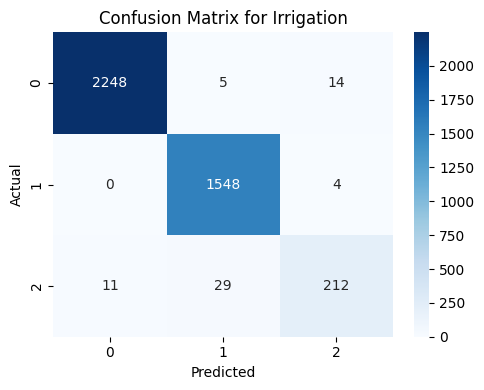

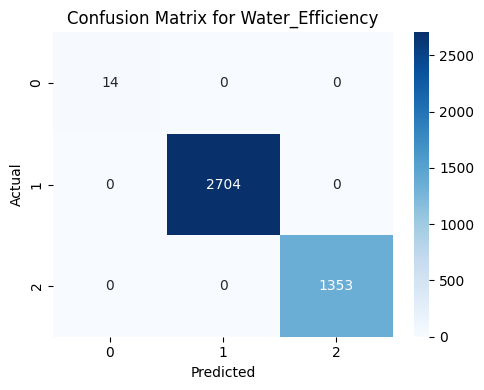

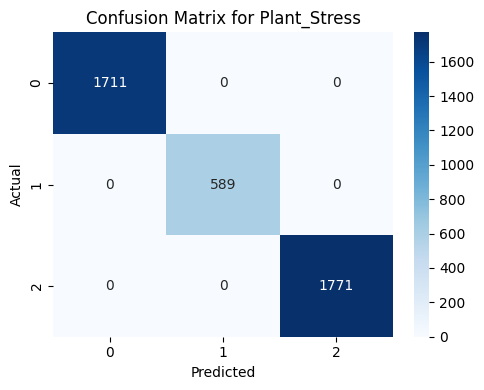

In [ ]:
# Confusion matrices for all targets
for i, target_name in enumerate(y.columns):
    # Compute confusion matrix for the current target
    cm = confusion_matrix(y_test.iloc[:, i], y_pred[:, i])

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {target_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


**Evaluation remark:**  
The performance for `Water_Efficiency` and `Plant_Stress` is almost perfect (close to 100% accuracy). This is expected because these two targets are rule-based features derived directly from the input variables. The model is essentially learning to reproduce our rules, so the high scores reflect the clarity of the rules rather than a very complex model.


--------------------------------------


Feature Importance for Irrigation:
  crop ID: 0.0337
  soil_type: 0.0259
  Seedling Stage: 0.0808
  MOI: 0.3646
  temp: 0.2813
  humidity: 0.2137


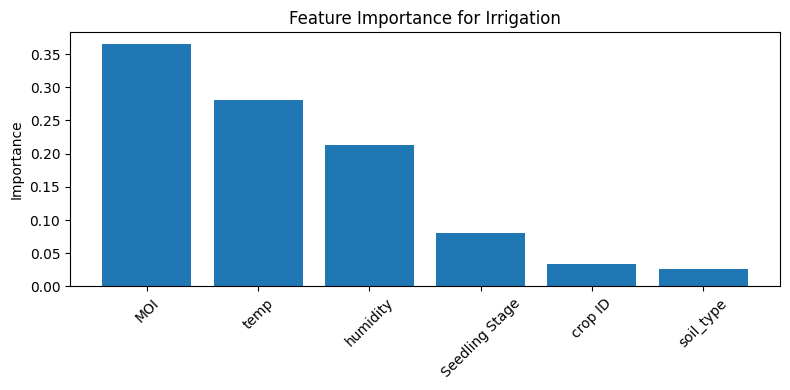


Feature Importance for Water_Efficiency:
  crop ID: 0.0010
  soil_type: 0.0007
  Seedling Stage: 0.0007
  MOI: 0.0687
  temp: 0.5039
  humidity: 0.4249


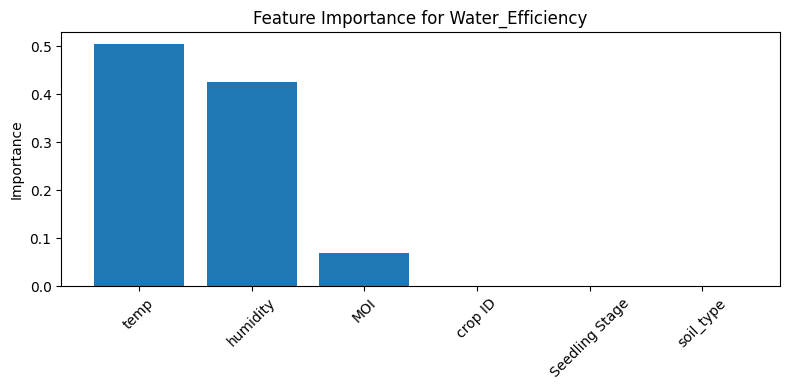


Feature Importance for Plant_Stress:
  crop ID: 0.0012
  soil_type: 0.0004
  Seedling Stage: 0.0006
  MOI: 0.0273
  temp: 0.5667
  humidity: 0.4038


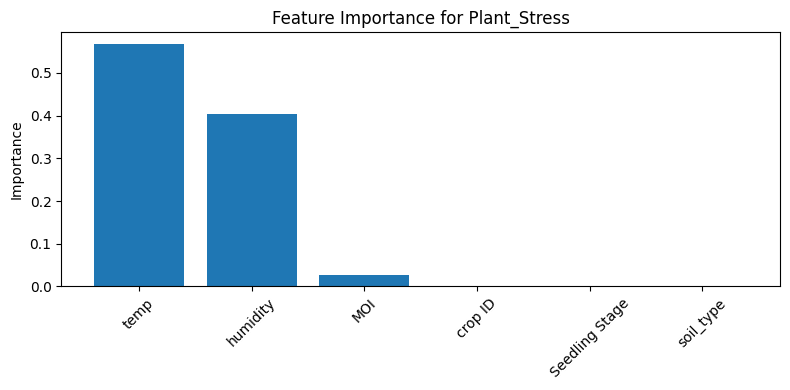

In [ ]:
# Feature importance for each target
for i, target_name in enumerate(y.columns):
    # Each estimator_ is a RandomForest trained for a specific target
    importances = model.estimators_[i].feature_importances_
    features = X.columns

    print(f"\nFeature Importance for {target_name}:")
    for f, imp in zip(features, importances):
        print(f"  {f}: {imp:.4f}")


    plt.figure(figsize=(8,4))
    # Sort features by importance (descending)
    indices = np.argsort(importances)[::-1]

    plt.title(f"Feature Importance for {target_name}")
    plt.bar(range(len(features)), importances[indices], align='center')
    plt.xticks(range(len(features)), features[indices], rotation=45)
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

**Feature importance insight:**  
Feature importance shows that environmental variables (`MOI`, `temp`, and `humidity`) dominate the model’s decisions, while `crop ID`, `soil_type`, and `Seedling Stage` have a much smaller impact. This confirms that irrigation and plant stress in this dataset are driven mainly by current environmental conditions.
